### NEO Risk Analysis

**Course:** CPE-551

This notebook analyzes near-Earth asteroid data from NASA's NeoWs API and applies a custom risk scoring system that improves on NASA's binary hazardous/non-hazardous classification by weighting asteroid diameter, velocity, and miss distance into a graduated 0-10 score.

### 1. Imports, Setup and Data Load

In [3]:
import math
import json
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

from asteroid import Asteroid
from asteroid_tracker import AsteroidTracker
from functions import calculate_risk_score, normalize_value

plt.rcParams["figure.figsize"] = (10, 6)

try:
    tracker = AsteroidTracker("data/data.json")
    print(f"Loaded {len(tracker)} asteroids from data/data.json")
except FileNotFoundError as e:
    print(f"Data file not found: {e}")
    raise
except json.JSONDecodeError as e:
    print(f"Could not parse JSON: {e}")
    raise

Loaded 29 asteroids from data/data.json


### 2. Basic Stats

Total asteroid count, date range, NASA hazardous count, and risk-category breakdown. Along with showcasing the date span via `datetime`. Compute the number of days covered by the dataset using the standard library `datetime` module

In [4]:
stats = tracker.get_summary_stats()

print("Dataset Summary")
print("-" * 40)
print(f"Total asteroids:    {stats['total_count']}")
print(f"Date range:         {stats['date_range'][0]} to {stats['date_range'][1]}")
print(f"NASA hazardous:     {stats['hazardous_count']}")
print(f"Mean risk score:    {stats['mean_risk']:.2f} / 10")
print(f"Max risk score:     {stats['max_risk']:.2f} / 10")
print(f"Min risk score:     {stats['min_risk']:.2f} / 10")
print("\nRisk category counts:")
for category, count in stats["category_counts"].items():
    print(f"  {category:<10} {count}")
start_str, end_str = stats["date_range"]
start_dt = datetime.strptime(start_str, "%Y-%m-%d")
end_dt = datetime.strptime(end_str, "%Y-%m-%d")
span_days = (end_dt - start_dt).days + 1
print(f"Dataset spans {span_days} days ({start_str} to {end_str}).")

Dataset Summary
----------------------------------------
Total asteroids:    29
Date range:         2026-05-05 to 2026-05-12
NASA hazardous:     1
Mean risk score:    2.98 / 10
Max risk score:     8.03 / 10
Min risk score:     0.81 / 10

Risk category counts:
  Low        10
  Medium     18
  High       0
  Critical   1
Dataset spans 8 days (2026-05-05 to 2026-05-12).


### 3. Top 10 Riskiest Asteroids

`get_top_risks(n)` sorts the collection by computed risk score and returns the top `n`. Each `Asteroid` defines `__str__` for a readable one-line summary and `__gt__` so comparisons work directly on score.

In [5]:
top10 = tracker.get_top_risks(10)

for i, asteroid in enumerate(top10, start=1):
    print(f"{i:>2}. {asteroid}")

 1. Asteroid 318411 (2005 AH14) | Diameter: 1635.1m | Miss: 14065559.3 km | Risk: 8.03 (Critical)
 2. Asteroid (2015 KB57) | Diameter: 149.1m | Miss: 21218744.9 km | Risk: 4.86 (Medium)
 3. Asteroid 326290 Akhenaten (1998 HE3) | Diameter: 185.2m | Miss: 11003043.9 km | Risk: 4.39 (Medium)
 4. Asteroid (2004 XA45) | Diameter: 271.4m | Miss: 68753396.5 km | Risk: 3.94 (Medium)
 5. Asteroid (2002 VU114) | Diameter: 118.5m | Miss: 18962019.0 km | Risk: 3.89 (Medium)
 6. Asteroid (2018 JN1) | Diameter: 149.1m | Miss: 27056382.4 km | Risk: 3.84 (Medium)
 7. Asteroid (2010 KC) | Diameter: 62.7m | Miss: 62234661.0 km | Risk: 3.64 (Medium)
 8. Asteroid (2018 DB2) | Diameter: 162.8m | Miss: 19435434.4 km | Risk: 3.40 (Medium)
 9. Asteroid (2007 VV83) | Diameter: 49.4m | Miss: 17143471.6 km | Risk: 3.32 (Medium)
10. Asteroid (2007 HW4) | Diameter: 81.9m | Miss: 45182093.8 km | Risk: 3.28 (Medium)


### 4. Build a DataFrame for Plotting

Use a list comprehension to extract per-asteroid fields, then load them into a pandas `DataFrame`. This makes the plots in the next sections easy to produce.

In [6]:
rows = [
    {
        "name": a.name,
        "avg_diameter_m": (a.diameter_min + a.diameter_max) / 2,
        "velocity_kmh": a.velocity,
        "miss_distance_km": a.miss_distance,
        "is_hazardous": a.is_hazardous,
        "close_approach_date": a.close_approach_date,
        "risk_score": a.calculate_risk_score(),
        "risk_category": a.get_risk_category(),
    }
    for a in tracker.asteroids
]

df = pd.DataFrame(rows)
df.head()

,name,avg_diameter_m,velocity_kmh,miss_distance_km,is_hazardous,close_approach_date,risk_score,risk_category
0,318411 (2005 AH14),1635.093593,47205.373220,1.406556e+07,False,2026-05-12,8.033794,Critical
1,(2010 GZ33),142.410699,60612.418952,7.080954e+07,False,2026-05-12,2.075395,Low
2,(2010 JR34),12.403453,31261.444826,2.153152e+07,False,2026-05-12,3.256562,Medium
3,(2010 KC),62.739726,109323.726804,6.223466e+07,False,2026-05-12,3.642270,Medium
4,(2018 VB10),29.753812,26339.833435,1.971642e+07,False,2026-05-12,3.247252,Medium


### 5. Scatter Plot for Size vs Miss Distance

Plot the `avg_diameter_m` and `miss_distance_km` data from `DataFrame` in a Scatter Plot.

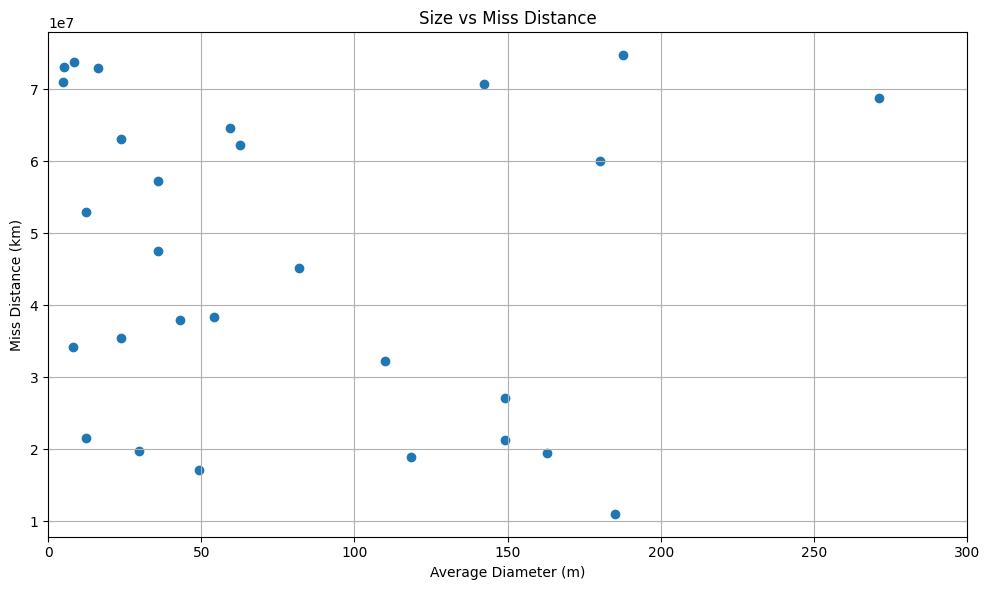

In [8]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df['avg_diameter_m'], 
    df['miss_distance_km']
)

plt.xlabel('Average Diameter (m)')
plt.ylabel('Miss Distance (km)')
plt.title('Size vs Miss Distance')
plt.grid(True)
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

### 6. Bar Chart: Threat Level Distribution

Display the distribution of asteroids across risk categories (`risk_category`: Low, Medium, High, Critical) using a Bar Chart.

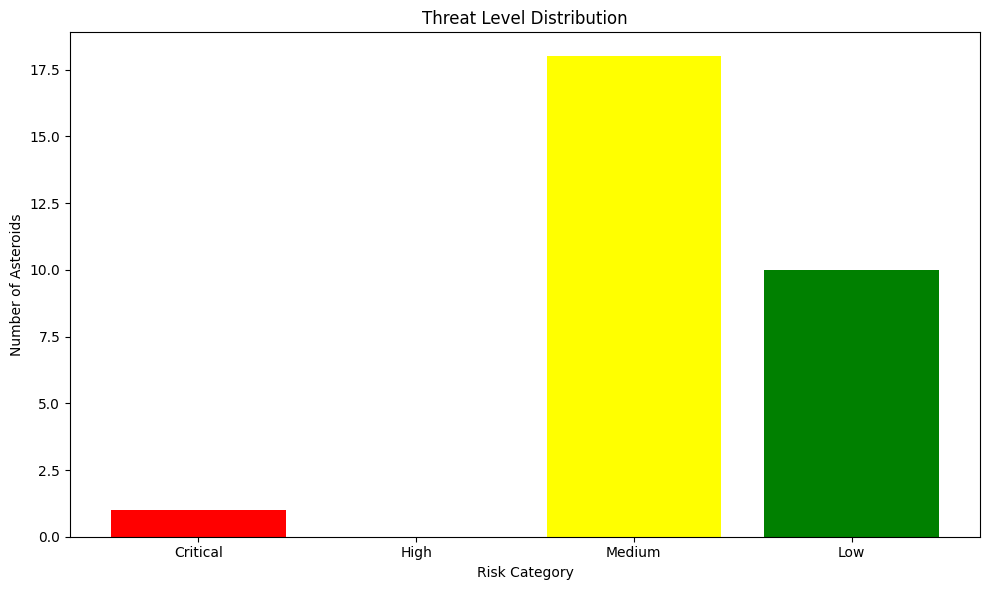

In [13]:
category_counts = df['risk_category'].value_counts()

category_order = ['Critical', 'High', 'Medium', 'Low']
colors = {'Critical': 'red', 'High': 'orange', 'Medium': 'yellow', 'Low': 'green'}
category_counts = category_counts.reindex(category_order)

plt.figure(figsize=(10, 6))
plt.bar(category_counts.index, category_counts.values, 
        color=[colors[cat] for cat in category_counts.index])
plt.xlabel('Risk Category')
plt.ylabel('Number of Asteroids')
plt.title('Threat Level Distribution')
plt.tight_layout()
plt.show()

### 7. Histogram: Risk Score Distribution

This histogram shows the distribution of `risk_score` across all the asteroids.

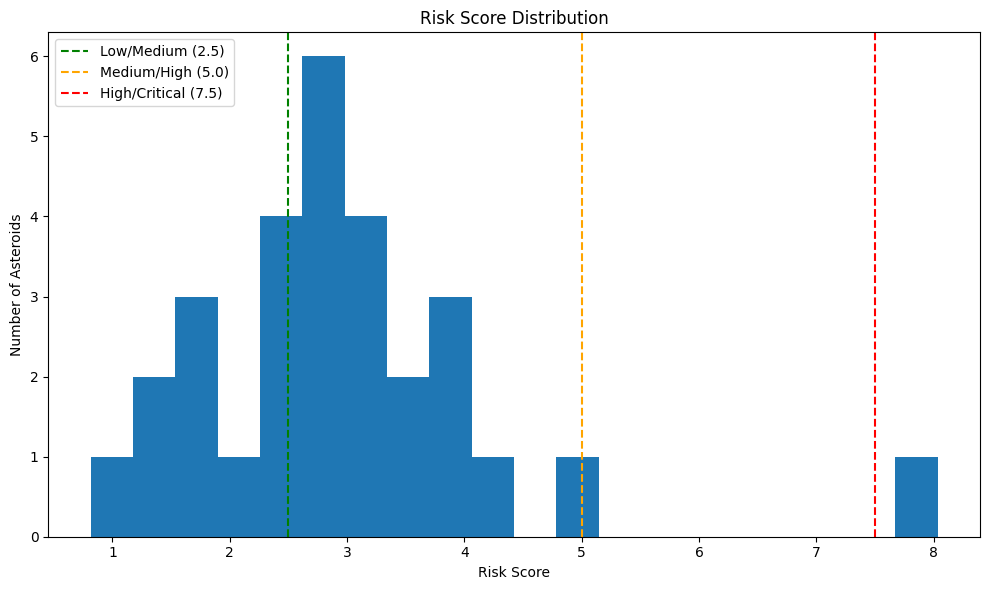

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(df['risk_score'], bins=20)

# Add vertical lines for risk category boundaries
plt.axvline(x=2.5, color='green', linestyle='--', label='Low/Medium (2.5)')
plt.axvline(x=5.0, color='orange', linestyle='--', label='Medium/High (5.0)')
plt.axvline(x=7.5, color='red', linestyle='--', label='High/Critical (7.5)')

plt.xlabel('Risk Score')
plt.ylabel('Number of Asteroids')
plt.title('Risk Score Distribution')
plt.legend()
plt.tight_layout()
plt.show()

### 8. Comparison: Custom Risk Score vs NASA Hazardous Classification

Compare the distribution of `risk_score` between asteroids NASA's `is_hazardous` classifications.

In [30]:
hazardous = df[df['is_hazardous'] == True]
non_hazardous = df[df['is_hazardous'] == False]

print("Comparison: Custom Risk Scores vs NASA Hazardous Classification:")

print(f"\nNASA Hazardous Asteroids):")
print(f"\nNumber of Asteroids: {len(hazardous)}")
print(f"Mean Risk Score: {hazardous['risk_score'].mean():.2f}")
print(f"Median Risk Score: {hazardous['risk_score'].median():.2f}")
print(f"Min Risk Score: {hazardous['risk_score'].min():.2f}")
print(f"Max Risk Score: {hazardous['risk_score'].max():.2f}")

print(f"\nNASA Non-Hazardous Asteroids:")
print(f"\nNumber of Asteroids: {len(non_hazardous)}")
print(f"Mean Risk Score: {non_hazardous['risk_score'].mean():.2f}")
print(f"Median Risk Score: {non_hazardous['risk_score'].median():.2f}")
print(f"Min Risk Score: {non_hazardous['risk_score'].min():.2f}")
print(f"Max Risk Score: {non_hazardous['risk_score'].max():.2f}")

high_risk_non_hazardous = non_hazardous[non_hazardous['risk_score'] >= 5.0]
print(f"\nNon-Hazardous Asteroids with Risk Score ≥ 5.0:")
print(f"Number of Asteroids: {len(high_risk_non_hazardous)}")
print(f"Mean Risk Score: {high_risk_non_hazardous['risk_score'].mean():.2f}")
print(f"Median Risk Score: {high_risk_non_hazardous['risk_score'].median():.2f}")
print(f"Min Risk Score: {high_risk_non_hazardous['risk_score'].min():.2f}")
print(f"Max Risk Score: {high_risk_non_hazardous['risk_score'].max():.2f}")

Comparison: Custom Risk Scores vs NASA Hazardous Classification:

NASA Hazardous Asteroids):

Number of Asteroids: 1
Mean Risk Score: 4.39
Median Risk Score: 4.39
Min Risk Score: 4.39
Max Risk Score: 4.39

NASA Non-Hazardous Asteroids:

Number of Asteroids: 28
Mean Risk Score: 2.93
Median Risk Score: 2.83
Min Risk Score: 0.81
Max Risk Score: 8.03

Non-Hazardous Asteroids with Risk Score ≥ 5.0:
Number of Asteroids: 1
Mean Risk Score: 8.03
Median Risk Score: 8.03
Min Risk Score: 8.03
Max Risk Score: 8.03


### 9. Summary Findings

Provides a summary of all the data findings.

In [45]:
print("Summary Findings:")

print(f"\nTotal Asteroids: {len(df)}")
print(f"Date Range: {stats['date_range'][0]} to {stats['date_range'][1]} ({span_days} days)")
print(f"NASA Hazardous: {df['is_hazardous'].sum()}")
print(f"Critical Risk: {category_counts.get('Critical', 0)}")
print(f"High Risk: {category_counts.get('High', 0)}")
print(f"Medium Risk: {category_counts.get('Medium', 0)}")
print(f"Low Risk: {category_counts.get('Low', 0)}")

print(f"\nMean Risk Score: {df['risk_score'].mean():.2f}")
print(f"Max Risk Score (Category): {df['risk_score'].max():.2f} ({df.loc[df['risk_score'].idxmax(), 'risk_category']})")
print(f"Min Risk Score (Category): {df['risk_score'].min():.2f} ({df.loc[df['risk_score'].idxmin(), 'risk_category']})")

print(f"\nHighest Risk Asteroid (Name): {df.loc[df['risk_score'].idxmax(), 'name']}")
print(f"Lowest Risk Asteroid (Name): {df.loc[df['risk_score'].idxmin(), 'name']}")

print(f"\nNASA Hazardous Asteroid Score (Category): {hazardous['risk_score'].iloc[0]:.2f} (Medium)")
print(f"Highest Non-Hazardous Asteroid Score (Category): {df['risk_score'].max():.2f} ({df.loc[df['risk_score'].idxmax(), 'risk_category']})")

Summary Findings:

Total Asteroids: 29
Date Range: 2026-05-05 to 2026-05-12 (8 days)
NASA Hazardous: 1
Critical Risk: 1.0
High Risk: nan
Medium Risk: 18.0
Low Risk: 10.0

Mean Risk Score: 2.98
Max Risk Score (Category): 8.03 (Critical)
Min Risk Score (Category): 0.81 (Low)

Highest Risk Asteroid (Name): 318411 (2005 AH14)
Lowest Risk Asteroid (Name): (2018 YO2)

NASA Hazardous Asteroid Score (Category): 4.39 (Medium)
Highest Non-Hazardous Asteroid Score (Category): 8.03 (Critical)
